# In Depth A/B Testing - Lab

## Introduction

In this lab, you'll explore a survey from Kaggle regarding budding data scientists. With this, you'll form some initial hypotheses, and test them using the tools you've acquired to date. 

## Objectives

You will be able to:
* Conduct t-tests and an ANOVA on a real-world dataset and interpret the results

In [1]:
#Your code here
!pip install -U fsds_100719
from fsds_100719.imports import *

fsds_1007219  v0.6.8 loaded.  Read the docs: https://fsds.readthedocs.io/en/latest/ 


Handle,Package,Description
dp,IPython.display,Display modules with helpful display and clearing commands.
fs,fsds_100719,Custom data science bootcamp student package
mpl,matplotlib,Matplotlib's base OOP module with formatting artists
plt,matplotlib.pyplot,Matplotlib's matlab-like plotting module
np,numpy,scientific computing with Python
pd,pandas,High performance data structures and tools
sns,seaborn,High-level data visualization library based on matplotlib


['[i] Pandas .iplot() method activated.']


## Load the Dataset and Perform a Brief Exploration



The data is stored in a file called **multipleChoiceResponses_cleaned.csv**. Feel free to check out the original dataset referenced at the bottom of this lab, although this cleaned version will undoubtedly be easier to work with. Additionally, meta-data regarding the questions is stored in a file name **schema.csv**. Load in the data itself as a Pandas DataFrame, and take a moment to briefly get acquainted with it.

> Note: If you can't get the file to load properly, try changing the encoding format as in `encoding='latin1'`

In [2]:
pd.set_option('max_colwidth', 10000)
pd.set_option('display.max_rows',0)
questions = pd.read_csv('schema.csv')
questions

,Column,Question,Asked
0,GenderSelect,Select your gender identity. - Selected Choice,All
1,GenderFreeForm,Select your gender identity. - A different identity - Text,All
2,Country,Select the country you currently live in.,All
3,Age,What's your age?,All
4,EmploymentStatus,What's your current employment status?,All
5,StudentStatus,Are you currently enrolled as a student at a degree granting school?,Non-worker
6,LearningDataScience,Are you currently focused on learning data science skills either formally or informally?,Non-worker
7,KaggleMotivationFreeForm,What's your motivation for being a Kaggle user?,Non-switcher
8,CodeWriter,"Do you write code to analyze data in your current job, freelance contracts, or most recent job if retired?",Worker1
...,...,...,...


In [3]:
df = pd.read_csv('multipleChoiceResponses_cleaned.csv',encoding='latin1')
df

//anaconda3/envs/learn-env/lib/python3.6/site-packages/IPython/core/interactiveshell.py:3058: DtypeWarning:

Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227) have mixed types. Specify dtype option on import or set low_memory=False.



,GenderSelect,Country,Age,EmploymentStatus,StudentStatus,LearningDataScience,CodeWriter,CareerSwitcher,CurrentJobTitleSelect,TitleFit,...,JobFactorTitle,JobFactorCompanyFunding,JobFactorImpact,JobFactorRemote,JobFactorIndustry,JobFactorLeaderReputation,JobFactorDiversity,JobFactorPublishingOpportunity,exchangeRate,AdjustedCompensation
0,"Non-binary, genderqueer, or gender non-conforming",NaN,NaN,Employed full-time,NaN,NaN,Yes,NaN,DBA/Database Engineer,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Female,United States,30.0,"Not employed, but looking for work",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Somewhat important,NaN,NaN,NaN,NaN
2,Male,Canada,28.0,"Not employed, but looking for work",NaN,NaN,NaN,NaN,NaN,NaN,...,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,NaN,NaN
3,Male,United States,56.0,"Independent contractor, freelancer, or self-employed",NaN,NaN,Yes,NaN,Operations Research Practitioner,Poorly,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,250000.0
4,Male,Taiwan,38.0,Employed full-time,NaN,NaN,Yes,NaN,Computer Scientist,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Male,Brazil,46.0,Employed full-time,NaN,NaN,Yes,NaN,Data Scientist,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Male,United States,35.0,Employed full-time,NaN,NaN,Yes,NaN,Computer Scientist,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Female,India,22.0,Employed full-time,NaN,NaN,No,Yes,Software Developer/Software Engineer,Fine,...,Very Important,Somewhat important,Somewhat important,Not important,Very Important,Very Important,Somewhat important,Somewhat important,NaN,NaN
8,Female,Australia,43.0,Employed full-time,NaN,NaN,Yes,NaN,Business Analyst,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.802310,64184.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


## Wages and Education

You've been asked to determine whether education is impactful to salary. Develop a hypothesis test to compare the salaries of those with Master's degrees to those with Bachelor's degrees. Are the two statistically different according to your results?

> Note: The relevant features are stored in the 'FormalEducation' and 'AdjustedCompensation' features.

You may import the functions stored in the `flatiron_stats.py` file to help perform your hypothesis tests. It contains the stats functions that you previously coded: `welch_t(a,b)`, `welch_df(a, b)`, and `p_value(a, b, two_sided=False)`. 

Note that `scipy.stats.ttest_ind(a, b, equal_var=False)` performs a two-sided Welch's t-test and that p-values derived from two-sided tests are two times the p-values derived from one-sided tests. See the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) for more information.    

In [4]:
#Your code here
df['FormalEducation'].value_counts()

Master's degree                                                      8204
Bachelor's degree                                                    4811
Doctoral degree                                                      3543
Some college/university study without earning a bachelor's degree     786
Professional degree                                                   451
I did not complete any formal education past high school              257
I prefer not to answer                                                 90
Name: FormalEducation, dtype: int64

In [5]:
df['FormalEducation'].value_counts(ascending=True).iplot('barh',theme='solar')

In [6]:
plt.style.use('dark_background')

In [7]:
# import missingno as ms
# ms.bar(df)

In [8]:
df.isna().sum().divide(len(df)).multiply(100).round(2)

GenderSelect                       0.40
Country                           25.14
Age                               25.93
EmploymentStatus                  24.75
StudentStatus                     95.05
LearningDataScience               95.00
CodeWriter                        38.05
CareerSwitcher                    88.47
CurrentJobTitleSelect             43.19
TitleFit                          44.42
CurrentEmployerType               44.14
MLToolNextYearSelect              46.48
                                  ...  
JobFactorExperienceLevel          86.98
JobFactorDepartment               87.06
JobFactorTitle                    87.07
JobFactorCompanyFunding           87.08
JobFactorImpact                   87.14
JobFactorRemote                   87.03
JobFactorIndustry                 87.08
JobFactorLeaderReputation         87.11
JobFactorDiversity                87.08
JobFactorPublishingOpportunity    87.03
exchangeRate                      82.95
AdjustedCompensation              83.55


In [9]:
df = df.dropna(subset=['AdjustedCompensation'])
df

,GenderSelect,Country,Age,EmploymentStatus,StudentStatus,LearningDataScience,CodeWriter,CareerSwitcher,CurrentJobTitleSelect,TitleFit,...,JobFactorTitle,JobFactorCompanyFunding,JobFactorImpact,JobFactorRemote,JobFactorIndustry,JobFactorLeaderReputation,JobFactorDiversity,JobFactorPublishingOpportunity,exchangeRate,AdjustedCompensation
3,Male,United States,56.0,"Independent contractor, freelancer, or self-employed",NaN,NaN,Yes,NaN,Operations Research Practitioner,Poorly,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,250000.000
8,Female,Australia,43.0,Employed full-time,NaN,NaN,Yes,NaN,Business Analyst,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.802310,64184.800
9,Male,Russia,33.0,Employed full-time,NaN,NaN,Yes,NaN,Software Developer/Software Engineer,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017402,20882.400
11,Male,India,27.0,Employed full-time,NaN,NaN,Yes,NaN,Data Scientist,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015620,1483.900
14,Male,Taiwan,26.0,Employed full-time,NaN,NaN,Yes,NaN,Software Developer/Software Engineer,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.033304,36634.400
21,Male,United States,25.0,Employed part-time,NaN,NaN,Yes,NaN,Researcher,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,20000.000
22,Male,United States,33.0,Employed full-time,NaN,NaN,Yes,NaN,Scientist/Researcher,Perfectly,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,100000.000
23,Male,Czech Republic,21.0,Employed part-time,NaN,NaN,Yes,NaN,Other,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.045820,916.400
25,Male,Russia,22.0,Employed full-time,NaN,NaN,Yes,NaN,Data Analyst,Fine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017402,10858.848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [12]:
# |setattr(df,'example','Demonstrating setattr with a')

[Text(0, 0.5, 'Adjusted Compensation')]

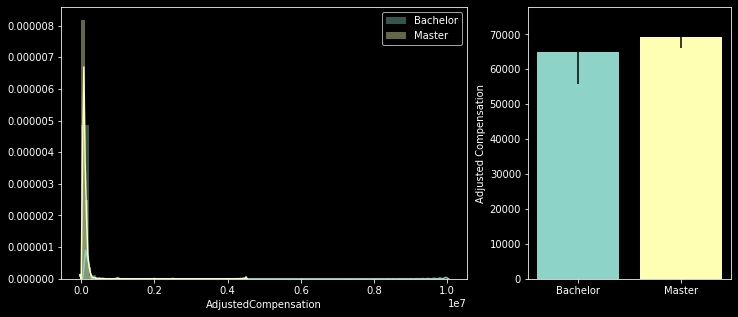

In [14]:
import scipy.stats as sp
df_b = df.groupby('FormalEducation').get_group("Bachelor's degree")['AdjustedCompensation']
df_m =df.groupby('FormalEducation').get_group("Master's degree")['AdjustedCompensation']

fig,axes=plt.subplots(ncols=2,figsize=(12,5),
                      gridspec_kw={'width_ratios':[2,1]})

ax=axes[0]
sns.distplot(df_b,ax=ax,label='Bachelor')
sns.distplot(df_m,ax=ax,label= 'Master')
ax.legend()

ax=axes[1]
ax.bar('Bachelor',df_b.mean(),yerr=sp.sem(df_b))
ax.bar('Master',df_m.mean(), yerr=sp.sem(df_m))
ax.set(ylabel='Adjusted Compensation')

In [15]:
# !pip install -U cufflinks
import cufflinks as cf
cf.go_offline()

In [19]:
df_b.iplot(kind='bar',theme='solar')

In [23]:
# df_b.iplot()
# sns.boxplot(df_b)

In [24]:
max(max(df_b),max(df_m))

9999999.0

In [34]:
print("Num Outliers (|Z|>3):")
print((np.abs(sp.zscore(df_b))>3).sum())

Num Outliers (|Z|>3):
3


In [36]:
(np.abs(sp.zscore(df_b))>3)

array([False, False, False, ..., False, False, False])

In [38]:
from ipywidgets import interact
max_range= max(max(df_b),max(df_m))
@interact(xmin=(0,max_range), xmax =(0,max_range))
def statplot_adjust(xmin=0,xmax=max_range):
    fig,axes=plt.subplots(ncols=2,figsize=(12,5),
                          gridspec_kw={'width_ratios':[2,1]})

    ax=axes[0]
    sns.distplot(df_b,ax=ax,label='Bachelor')
    sns.distplot(df_m,ax=ax,label= 'Master')
    ax.legend()

    ax=axes[1]
    ax.bar('Bachelor',df_b.mean(),yerr=sp.sem(df_b))
    ax.bar('Master',df_m.mean(), yerr=sp.sem(df_m))
    ax.set(ylabel='Adjusted Compensation')
    
    axes[0].grid()
    axes[0].set_xlim(left=xmin,right=xmax)

interactive(children=(FloatSlider(value=0.0, description='xmin', max=9999999.0), FloatSlider(value=9999999.0, …

In [39]:
import scipy.stats as sp
sp.sem(df_b)

9225.158530746601

In [40]:
df_b = df_b.rename('bachelors')
df_m = df_m.rename('masters')

In [41]:
# plot_df = pd.concat([df_b,df_m],axis=1)
# plot_df

In [42]:
# sns.swarmplot(plot_df)

In [43]:
sp.normaltest(df_b), sp.normaltest(df_m)

(NormaltestResult(statistic=2990.1583342270997, pvalue=0.0),
 NormaltestResult(statistic=4638.387006324077, pvalue=0.0))

In [44]:
u,p = sp.mannwhitneyu(df_b,df_m)
p<.05

True

## Wages and Education II

Now perform a similar statistical test comparing the AdjustedCompensation of those with Bachelor's degrees and those with Doctorates. If you haven't already, be sure to explore the distribution of the AdjustedCompensation feature for any anomalies. 

In [ ]:
#Your code here

## Wages and Education III

Remember the multiple comparisons problem; rather than continuing on like this, perform an ANOVA test between the various 'FormalEducation' categories and their relation to 'AdjustedCompensation'.

In [ ]:
#Your code here

## Additional Resources

Here's the original source where the data was taken from:  
    [Kaggle Machine Learning & Data Science Survey 2017](https://www.kaggle.com/kaggle/kaggle-survey-2017)

## Summary

In this lab, you practiced conducting actual hypothesis tests on actual data. From this, you saw how dependent results can be on the initial problem formulation, including preprocessing!